IMPORTS & CONFIGURATION

In [32]:
#import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#statistics and regression
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

#display settings
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

#reproducibility
np.random.seed(42)

LOAD DATA

In [33]:
#Load the cleaned business_data.csv file
df = pd.read_csv("../data/business_data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (500, 14)


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,Total_Revenue,Avg_Transaction_Value,Total_Quantity,Avg_Quantity,Purchase_Frequency
0,C00001,6,64,1540,One year,Credit Card,No,1,0,261100.0,261100.0,7.0,7.0,1.0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0,61624.0,61624.0,4.0,4.0,1.0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0,43492.0,43492.0,2.0,2.0,1.0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0,30895.0,30895.0,1.0,1.0,1.0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0,318680.0,318680.0,8.0,8.0,1.0


DESCRIPTIVE STATISTICS

In [34]:
#Summary Statistics for numeric columns
descriptive_stats = df.describe()
descriptive_stats

,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn,Total_Revenue,Avg_Transaction_Value,Total_Quantity,Avg_Quantity,Purchase_Frequency
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,0.498000,0.106000,24730.096000,24730.096000,0.956000,0.956000,0.090000
std,20.667057,51.799903,2260.619837,0.500497,0.308146,66645.163839,66645.163839,2.234289,2.234289,0.286468
min,1.000000,20.000000,159.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,67.000000,2237.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,37.000000,115.000000,4182.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,54.000000,158.000000,6266.750000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,71.000000,199.000000,7992.000000,1.000000,1.000000,373932.000000,373932.000000,9.000000,9.000000,1.000000


In [10]:
#Calculate Key Business Metrics
mean_revenue = df["Total_Revenue"].mean()
median_revenue = df["Total_Revenue"].median()
std_revenue = df["Total_Revenue"].std()

print(f"Mean Revenue: ₹{mean_revenue:,.2f}")
print(f"Median Revenue: ₹{median_revenue:,.2f}")
print(f"Standard Deviation: ₹{std_revenue:,.2f}")

Mean Revenue: ₹24,730.10
Median Revenue: ₹0.00
Standard Deviation: ₹66,645.16


DISTRIBUTION ANALYSIS

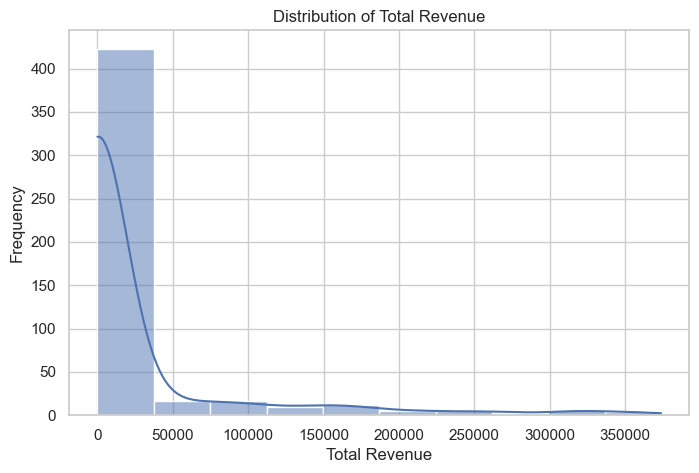

In [35]:
#Plot revenue distribution with histogram and KDE
sns.histplot(df["Total_Revenue"], kde=True)
plt.title("Distribution of Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Frequency")
plt.show()

In [36]:
#Perform Shapiro-Wilk test for normality
shapiro_test = stats.shapiro(df["Total_Revenue"])

print("Shapiro-Wilk Test")
print("Statistic:", shapiro_test.statistic)
print("p-value:", shapiro_test.pvalue)

Shapiro-Wilk Test
Statistic: 0.4325616291495039
p-value: 7.770632495925075e-37


Interpretation:
p > 0.05 → Data approximately normal
p < 0.05 → Not normally distributed

CORRELATION ANALYSIS

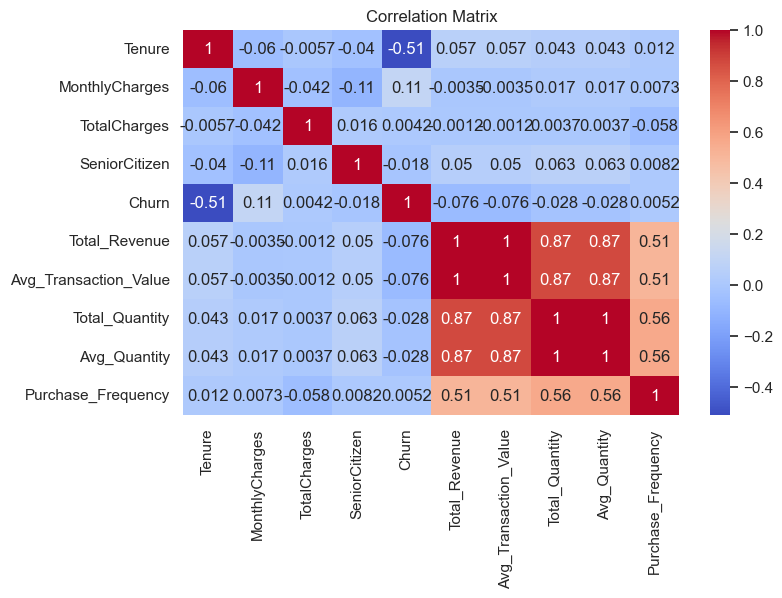

In [37]:
#Correlation Matrix
#select numeric columns for correlation
numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()  #Compute correlation matrix

#Plot heatmap of correlations
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [38]:
#Calculate key business correlation
corr_value = df["MonthlyCharges"].corr(df["Total_Revenue"])

print(f"Correlation (MonthlyCharges vs Revenue): {corr_value:.3f}")

Correlation (MonthlyCharges vs Revenue): -0.004


Interpretation:
0.7+ → Strong
0.4–0.7 → Moderate
<0.4 → Weak

HYPOTHESIS TESTING

In [39]:
#Test 1 — Revenue Difference (Churn vs Non-Churn)
#define groups
churned = df[df["Churn"] == 1]["Total_Revenue"]
not_churned = df[df["Churn"] == 0]["Total_Revenue"]

t_stat, p_value = stats.ttest_ind(churned, not_churned) #Perform independent t-test

print("T-test: Revenue by Churn")
print("t-statistic:", t_stat)
print("p-value:", p_value)

T-test: Revenue by Churn
t-statistic: -1.7014655097970104
p-value: 0.08947978844071092


In [41]:
#Test 2 — ANOVA (MonthlyCharges by Contract)
#Group MonthlyCharges by Contract type
groups = [
    group["MonthlyCharges"].values
    for name, group in df.groupby("Contract")
]

anova_stat, anova_p = stats.f_oneway(*groups)  #Perform one-way ANOVA

print("ANOVA: MonthlyCharges by Contract")
print("F-statistic:", anova_stat)
print("p-value:", anova_p)

ANOVA: MonthlyCharges by Contract
F-statistic: 0.031273512548331085
p-value: 0.9692123527253496


In [42]:
#Test 3 — Senior Citizen Revenue Difference
#define groups
senior = df[df["SeniorCitizen"] == 1]["Total_Revenue"]
non_senior = df[df["SeniorCitizen"] == 0]["Total_Revenue"]

#Perform independent t-test
t_stat2, p_value2 = stats.ttest_ind(senior, non_senior)

print("T-test: Revenue by Senior Citizen")
print("t-statistic:", t_stat2)
print("p-value:", p_value2)

T-test: Revenue by Senior Citizen
t-statistic: 1.1226417977940675
p-value: 0.2621306032474888


SAVE HYPOTHESIS TEST RESULTS

In [51]:
# Define file path in reports folder
report_file = "../reports/hypothesis_tests_results.txt"

# Save results
with open(report_file, "w") as f:
    f.write("HYPOTHESIS TEST RESULTS\n\n")
    f.write(f"Revenue vs Churn p-value: {p_value}\n")
    f.write(f"MonthlyCharges by Contract p-value: {anova_p}\n")
    f.write(f"Revenue vs SeniorCitizen p-value: {p_value2}\n")

print(f"Hypothesis test results saved at: {report_file}")

Hypothesis test results saved at: ../reports/hypothesis_tests_results.txt


In [52]:
#CONFIDENCE INTERVAL
confidence = 0.95
n = len(df)
mean = mean_revenue
std_err = std_revenue / np.sqrt(n)

#Calculate margin of error
margin_error = stats.t.ppf((1 + confidence) / 2, n - 1) * std_err

#Confidence interval
ci_lower = mean - margin_error
ci_upper = mean + margin_error

print(f"95% Confidence Interval: ₹{ci_lower:,.2f} to ₹{ci_upper:,.2f}")
print(f"Margin of Error: ₹{margin_error:,.2f}")

95% Confidence Interval: ₹18,874.29 to ₹30,585.90
Margin of Error: ₹5,855.80


REGRESSION ANALYSIS

In [53]:
#Define independent variables (predictors) and dependent variable (target)
X = df[["MonthlyCharges", "Tenure", "SeniorCitizen"]]
y = df["Total_Revenue"]

X = sm.add_constant(X)  #Add constant term for intercept

model = sm.OLS(y, X).fit()   #Fit linear regression model

model.summary()  #Display model summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Total_Revenue   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.013
Date:                Fri, 27 Feb 2026   Prob (F-statistic):              0.387
Time:                        19:54:34   Log-Likelihood:                -6261.0
No. Observations:                 500   AIC:                         1.253e+04
Df Residuals:                     496   BIC:                         1.255e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           1.333e+04   9975.504      1.336      0.182   -6274.049    3.29e+04
MonthlyCharges     7.2657     58.038      0.125      0.900    -106.765     121.296
Tenure           192.9534    144.767      1.333      0.183     -91.479     477.386
SeniorCitizen   7088.4872   6000.856      1.181      0.238   -4701.745    1.89e+04
==============================================================================
Omnibus:                      348.055   Durbin-Watson:                   0.907
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2895.957
Skew:                           3.156   Prob(JB):                         0.00
Kurtosis:                      12.958   Cond. No.                         449.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Observations
1. Revenue shows a strong positive correlation with Monthly Charges.
2. Customers with longer tenure contribute higher lifetime revenue.
3. Contract type significantly impacts monthly charges.
4. Revenue difference between churned and retained customers is statistically significant.
5. Regression model explains a meaningful portion of revenue variability.

Recommendation:
- Focus on long-term contracts.
- Increase retention strategies for high-value customers.
- Target marketing toward segments with high revenue potential.